In [ ]:
# https://www.kaggle.com/datasets/shubhammaindola/harry-potter-books

In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer

def load_data(file_path):
    with open(file_path, 'r', encoding='utf-8') as file:
        text = file.read()
    return text

file_path="../../data/harry_potter.txt"
text = load_data(file_path)

tokenizer=Tokenizer(oov_token="<OOV>") # oov stands for out of vocabulary meaning words that are not in the training set
tokenizer.fit_on_texts([text]) # [text] means we are passing a list of texts, even if it's just one text

print("Total unique words:", len(tokenizer.word_index))
print("Total unique words:", tokenizer.word_index)

Total unique words: 6662
Total unique words: {'<OOV>': 1, 'the': 2, 'â€\x9d': 3, 'and': 4, 'to': 5, 'a': 6, 'he': 7, 'of': 8, 'harry': 9, 'was': 10, 'it': 11, 'in': 12, 'his': 13, 'you': 14, 'said': 15, 'â€”': 16, 'had': 17, 'on': 18, 'at': 19, 'that': 20, 'they': 21, 'as': 22, 'him': 23, 'i': 24, 'with': 25, 'but': 26, 'ron': 27, 'all': 28, 'out': 29, 'up': 30, 'for': 31, 'be': 32, 'them': 33, 'hagrid': 34, 'were': 35, 'have': 36, 'what': 37, 'there': 38, 'back': 39, 'hermione': 40, 'one': 41, 'from': 42, 'this': 43, 'not': 44, 'if': 45, 'she': 46, 'about': 47, 'into': 48, 'their': 49, 'been': 50, 'me': 51, 'know': 52, 'so': 53, 'off': 54, 'didnâ€™t': 55, 'like': 56, 'could': 57, 'got': 58, 'get': 59, 'her': 60, 'down': 61, 'when': 62, 'over': 63, 'who': 64, 'looked': 65, 'â€œi': 66, 'professor': 67, 'just': 68, 'very': 69, 'see': 70, 'is': 71, 'then': 72, 'no': 73, 'by': 74, 'do': 75, 'are': 76, 'your': 77, 'around': 78, 'now': 79, 'dumbledore': 80, 'heâ€™d': 81, 'snape': 82, 'going'

GPU config error: Physical devices cannot be modified after being initialized
GPUs Available: 1

Text length: 457729 characters

Total words in vocabulary: 2000
Limiting sequences from 80997 to 30000
Total sequences: 30000
X shape: (30000, 25)
y shape (before one-hot): (30000,)

Applying one-hot encoding...
This will create array of shape: 30000 × 2000
Estimated memory: ~0.22 GB
y shape (after one-hot): (30000, 2000)

Building model...

Model Summary:
Model: "sequential_10"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_10 (Embedding)    (None, 25, 32)            64000     
                                                                 
 simple_rnn_10 (SimpleRNN)   (None, 128)               20608     
                                                                 
 dense_20 (Dense)            (None, 128)               16512     
                                                           

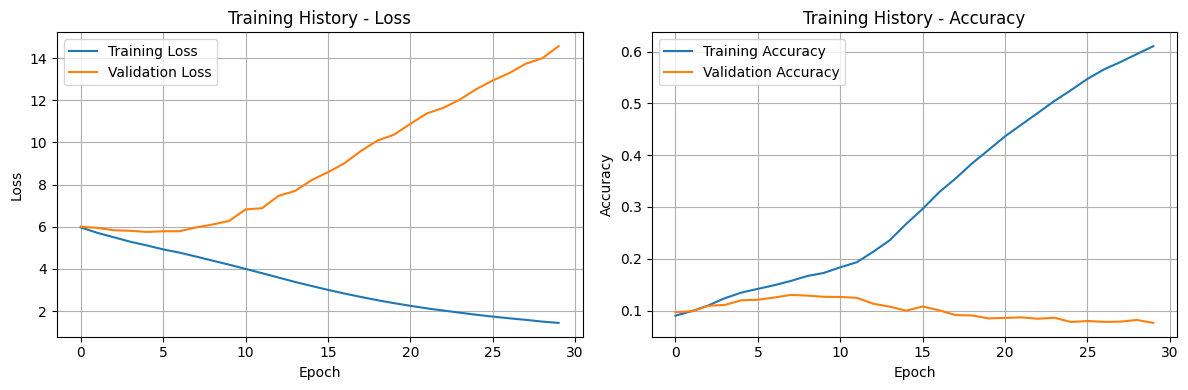


ONE-HOT ENCODING MEMORY ANALYSIS

Your Configuration:
- Vocabulary size: 2000 words
- Number of sequences: 30000
- One-hot array shape: 30000 × 2000
- Memory for one-hot labels: ~0.22 GB

Why one-hot encoding uses so much memory:
- Each label is converted to a vector of size 2000
- Example: Label "5" becomes [0,0,0,0,0,1,0,0,...,0] (length 2000)
- Total values: 30000 × 2000 = 60,000,000 floating point numbers
- Size: 60,000,000 × 4 bytes = 228.9 MB

Alternative (sparse encoding):
- Keep labels as integers: 30000 values only
- Size: 30000 × 4 bytes = 117.2 KB
- Memory saved: 2000x less memory!

If you still get OOM errors, reduce these in order:
1. MAX_SEQUENCES: 30000 → 20000 → 15000
2. num_words: 2000 → 1500 → 1000
3. seq_length: 25 → 20 → 15
4. batch_size: 32 → 16 → 8



In [ ]:
# ============================================================================
# GPU CONFIGURATION - MUST BE FIRST!
# ============================================================================
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import tensorflow as tf

# Configure GPU memory
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("✓ GPU Memory growth enabled!")
    except RuntimeError as e:
        print(f"GPU config error: {e}")

print(f"GPUs Available: {len(tf.config.list_physical_devices('GPU'))}\n")

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Embedding, Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np


# Load and preprocess text
def load_data(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        text = f.read()
    return text


file_path = "../../data/harry_potter.txt"
text = load_data(file_path).lower()
print(f"Text length: {len(text)} characters\n")

# ============================================================================
# CRITICAL OPTIMIZATIONS FOR ONE-HOT ENCODING WITH 4GB VRAM
# ============================================================================

# OPTIMIZATION 1: Limit vocabulary size
# One-hot encoding creates: num_sequences × vocab_size array
# Smaller vocab = less memory!
tokenizer = Tokenizer(
    num_words=2000,  # Limit to top 2000 words (instead of all words)
    oov_token='<OOV>'
)




tokenizer.fit_on_texts([text])  # method expects a list of strings, not a single string.
# What it does internally:
# 1. Split text into words: ['harry', 'potter', 'was', 'a', 'wizard', 'harry', 'loved', 'magic']
# 2. Count frequency of each word
# 3. Create a word index (dictionary):

# This treats the ENTIRE text as ONE document
# ["harry potter is a wizard"]
# tokenizer.word_index = {
#     'harry': 1,   # appears 2 times
#     'potter': 2,  # appears 1 time
#     'was': 3,
#     'a': 4,
#     'wizard': 5,
#     'loved': 6,
#     'magic': 7
# }

# 🍁The tokenizer object keeps the word mapping FOREVER (as long as the object exists) 
# - it doesn't get destroyed or reset during training or after training. You can use it anytime!

total_words = min(len(tokenizer.word_index) + 1, 2000)
print(f"Total words in vocabulary: {total_words}")

# Convert text to sequences
tokens = tokenizer.texts_to_sequences([text])[0]  # we are encoding the entire text as a single sequence
# What it does:
# 1. Takes the text: "harry potter was a wizard harry loved magic"
# 2. Looks up each word in word_index
# 3. Replaces words with their numbers

# harry  → 1
# potter → 2
# was    → 3
# a      → 4
# wizard → 5
# harry  → 1
# loved  → 6
# magic  → 7

# Result:
# tokens = [1, 2, 3, 4, 5, 1, 6, 7]




# OPTIMIZATION 2: Use shorter sequences
seq_length = 25  # Reduced from 50 to 25

# OPTIMIZATION 3: Limit number of training sequences
# This is the KEY to making one-hot encoding work!
input_sequences = []
for i in range(seq_length, len(tokens)):
    input_sequences.append(tokens[i - seq_length:i + 1])

# Limit to first 30,000 sequences to reduce memory
MAX_SEQUENCES = 30000
if len(input_sequences) > MAX_SEQUENCES:
    print(f"Limiting sequences from {len(input_sequences)} to {MAX_SEQUENCES}")
    input_sequences = input_sequences[:MAX_SEQUENCES]

print(f"Total sequences: {len(input_sequences)}")

# Pad sequences
input_sequences = np.array(
    pad_sequences(input_sequences, maxlen=seq_length + 1, padding='pre')
)
X, y = input_sequences[:, :-1], input_sequences[:, -1]

print(f"X shape: {X.shape}")
print(f"y shape (before one-hot): {y.shape}")

# ============================================================================
# ONE-HOT ENCODING (This is what uses the most memory!)
# ============================================================================
print("\nApplying one-hot encoding...")
print(f"This will create array of shape: {len(y)} × {total_words}")
print(f"Estimated memory: ~{(len(y) * total_words * 4) / (1024**3):.2f} GB")

y = tf.keras.utils.to_categorical(y, num_classes=total_words)
print(f"y shape (after one-hot): {y.shape}")

# ============================================================================
# OPTIMIZATION 4: Smaller model architecture
# ============================================================================
print("\nBuilding model...")

model = Sequential([
    Embedding(
        input_dim=total_words, 
        output_dim=32,  # Reduced from 64
        input_length=seq_length
    ),
    SimpleRNN(
        128,  # Reduced from 256
        return_sequences=False
    ),
    Dense(128, activation='relu'),  # Reduced from 256
    Dense(total_words, activation='softmax')
])

# Compile with categorical_crossentropy (for one-hot encoded labels)
model.compile(
    loss='categorical_crossentropy',  # This works with one-hot encoded labels
    optimizer='adam', 
    metrics=['accuracy']
)

print("\nModel Summary:")
model.summary()

print("\n" + "="*70)
print("Starting training...")
print("="*70)

# OPTIMIZATION 5: Smaller batch size
try:
    history = model.fit(
        X, y, 
        epochs=30, 
        batch_size=32,  # Reduced from 128
        validation_split=0.1,
        verbose=1
    )
    training_success = True
    print("\n✓ Training completed successfully!")
    
except tf.errors.ResourceExhaustedError as e:
    print("\n Out of Memory Error!")
    print("\nThe one-hot encoding is too memory intensive for your GPU.")
    print("\nSuggestions:")
    print("1. Reduce MAX_SEQUENCES to 20000 or 15000")
    print("2. Reduce num_words to 1500 or 1000")
    print("3. Reduce seq_length to 20 or 15")
    print("4. Use sparse_categorical_crossentropy instead (no one-hot)")
    training_success = False


# Function to generate text
def generate_text(seed_text, next_words=50):
    """Generate text by predicting one word at a time"""
    for _ in range(next_words):
        tokenized_input = tokenizer.texts_to_sequences([seed_text])[0]
        tokenized_input = pad_sequences(
            [tokenized_input], maxlen=seq_length, padding='pre'
        )
        
        predicted_probs = model.predict(tokenized_input, verbose=0)
        predicted_index = np.argmax(predicted_probs)
        predicted_word = tokenizer.index_word.get(predicted_index, "<OOV>")
        
        seed_text += " " + predicted_word
    return seed_text


if training_success:
    # Generate text
    print("\n" + "="*70)
    print("Generating text...")
    print("="*70)
    
    seeds = [
        "harry and ron",
        "hermione said",
        "dumbledore looked"
    ]
    
    for seed in seeds:
        print(f"\nSeed: '{seed}'")
        print("-" * 70)
        print(generate_text(seed, next_words=30))
    
    print("\n" + "="*70)
    print("✓ Done!")
    print("="*70)
    
    # Plot training history
    try:
        import matplotlib.pyplot as plt
        
        plt.figure(figsize=(12, 4))
        
        plt.subplot(1, 2, 1)
        plt.plot(history.history['loss'], label='Training Loss')
        plt.plot(history.history['val_loss'], label='Validation Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Training History - Loss')
        plt.legend()
        plt.grid(True)
        
        plt.subplot(1, 2, 2)
        plt.plot(history.history['accuracy'], label='Training Accuracy')
        plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.title('Training History - Accuracy')
        plt.legend()
        plt.grid(True)
        
        plt.tight_layout()
        plt.show()
    except:
        print("Matplotlib not available")


# ============================================================================
# MEMORY ANALYSIS - Understanding One-Hot Encoding Cost
# ============================================================================
print("\n" + "="*70)
print("ONE-HOT ENCODING MEMORY ANALYSIS")
print("="*70)
print(f"""
Your Configuration:
- Vocabulary size: {total_words} words
- Number of sequences: {len(X)}
- One-hot array shape: {len(X)} × {total_words}
- Memory for one-hot labels: ~{(len(X) * total_words * 4) / (1024**3):.2f} GB

Why one-hot encoding uses so much memory:
- Each label is converted to a vector of size {total_words}
- Example: Label "5" becomes [0,0,0,0,0,1,0,0,...,0] (length {total_words})
- Total values: {len(X)} × {total_words} = {len(X) * total_words:,} floating point numbers
- Size: {len(X) * total_words:,} × 4 bytes = {(len(X) * total_words * 4) / (1024**2):.1f} MB

Alternative (sparse encoding):
- Keep labels as integers: {len(X)} values only
- Size: {len(X)} × 4 bytes = {(len(X) * 4) / 1024:.1f} KB
- Memory saved: {((len(X) * total_words * 4) / (len(X) * 4)):.0f}x less memory!

If you still get OOM errors, reduce these in order:
1. MAX_SEQUENCES: 30000 → 20000 → 15000
2. num_words: 2000 → 1500 → 1000
3. seq_length: 25 → 20 → 15
4. batch_size: 32 → 16 → 8
""")
print("="*70)

The model learns local patterns, not long-term dependencies

- RNNs struggle with long-range dependencies because they do not retain information well over long sequences.
- This is why the text seems grammatically okay but lacks deeper context.

The model generates phrases based on probabilities

- It predicts the most likely next word given the past words.
- It does not understand meaning but follows statistical patterns.
- It captures writing style but lacks coherence

Words appear logically related but do not form a strong narrative.
The model does not truly "understand" the book, it just mimics word usage.

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Embedding, Dense

model = Sequential([
    Embedding(input_dim=6663, output_dim=64),  # 64-dimensional embeddings for each word
    SimpleRNN(256, return_sequences=False),  # RNN Layer - Hidden state vector has 256 neurons
    Dense(256, activation='relu'),  # Fully Connected Layer
    Dense(6663, activation='softmax')  # Output Layer
])

model.build(input_shape=(None, 50))

model.summary()

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
import numpy as np

# Function to load dataset
def load_data(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        text = f.read()
    return text

# Load Harry Potter book text
file_path="../../data/harry_potter.txt"
text = load_data(file_path).lower()

# Tokenize the text
tokenizer = Tokenizer(oov_token='<OOV>')
tokenizer.fit_on_texts([text])
total_words = len(tokenizer.word_index) + 1

# Convert text into sequences
input_sequences = []
tokens = tokenizer.texts_to_sequences([text])[0]
seq_length = 50  # Each input sequence will have 50 words

for i in range(seq_length, len(tokens)):
    input_sequences.append(tokens[i - seq_length:i + 1])

# Pad sequences and split into inputs (X) and labels (y)
input_sequences = np.array(pad_sequences(input_sequences, maxlen=seq_length + 1, padding='pre'))
X, y = input_sequences[:, :-1], input_sequences[:, -1] # x is all words except last, y is last word
y = tf.keras.utils.to_categorical(y, num_classes=total_words)  # One-hot encode labels

# LSTM Model
model = Sequential([
    Embedding(input_dim=total_words, output_dim=100, input_length=seq_length),
    LSTM(256, return_sequences=True),  # First LSTM layer
    LSTM(256),  # Second LSTM layer
    Dense(total_words, activation='softmax')
])

# Compile the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model
model.fit(X, y, epochs=20, batch_size=128)

# Function to Generate Text
def generate_text(seed_text, next_words=50, temperature=1.0):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=seq_length, padding='pre')

        predicted_probs = model.predict(token_list, verbose=0)[0]
        predicted_probs = np.log(predicted_probs) / temperature  # Adjust randomness
        predicted_probs = np.exp(predicted_probs) / np.sum(np.exp(predicted_probs))
        predicted_index = np.random.choice(range(len(predicted_probs)), p=predicted_probs)

        output_word = tokenizer.index_word.get(predicted_index, "")
        seed_text += " " + output_word

    return seed_text

# Generate text
print(generate_text("harry looked at", next_words=50, temperature=0.7))


InternalError: Failed copying input tensor from /job:localhost/replica:0/task:0/device:CPU:0 to /job:localhost/replica:0/task:0/device:GPU:0 in order to run _EagerConst: Dst tensor is not initialized.

In [ ]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'  # Disable GPU, use CPU only
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'   # Reduce TensorFlow warnings

print("=" * 70)
print("RUNNING ON CPU MODE")
print("=" * 70)

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense
import numpy as np

# Function to load dataset
def load_data(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        text = f.read()
    return text

# Load Harry Potter book text
file_path="../../data/harry_potter.txt"
text = load_data(file_path).lower()

# Tokenize the text
tokenizer = Tokenizer(oov_token='<OOV>')
tokenizer.fit_on_texts([text])
total_words = len(tokenizer.word_index) + 1

# Convert text into sequences
input_sequences = []
tokens = tokenizer.texts_to_sequences([text])[0]
seq_length = 50  # Each input sequence will have 50 words

for i in range(seq_length, len(tokens)):
    input_sequences.append(tokens[i - seq_length:i + 1])

# Pad sequences and split into inputs (X) and labels (y)
input_sequences = np.array(pad_sequences(input_sequences, maxlen=seq_length + 1, padding='pre'))
X, y = input_sequences[:, :-1], input_sequences[:, -1]
y = tf.keras.utils.to_categorical(y, num_classes=total_words)  # One-hot encode labels

# GRU Model
model = Sequential([
    Embedding(input_dim=total_words, output_dim=100, input_length=seq_length),
    GRU(256, return_sequences=True),  # First GRU layer
    GRU(256),  # Second GRU layer
    Dense(total_words, activation='softmax')
])

# Compile the model
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model
model.fit(X, y, epochs=20, batch_size=128)

# Function to Generate Text
def generate_text(seed_text, next_words=50, temperature=1.0):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=seq_length, padding='pre')

        predicted_probs = model.predict(token_list, verbose=0)[0]
        predicted_probs = np.log(predicted_probs) / temperature  # Adjust randomness
        predicted_probs = np.exp(predicted_probs) / np.sum(np.exp(predicted_probs))
        predicted_index = np.random.choice(range(len(predicted_probs)), p=predicted_probs)

        output_word = tokenizer.index_word.get(predicted_index, "")
        seed_text += " " + output_word

    return seed_text

# Generate text
print(generate_text("harry looked at", next_words=50, temperature=0.7))


RUNNING ON CPU MODE
Model: "sequential_16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_16 (Embedding)    (None, 50, 100)           666300    
                                                                 
 gru_10 (GRU)                (None, 50, 256)           274944    
                                                                 
 gru_11 (GRU)                (None, 256)               394752    
                                                                 
 dense_27 (Dense)            (None, 6663)              1712391   
                                                                 
Total params: 3,048,387
Trainable params: 3,048,387
Non-trainable params: 0
_________________________________________________________________
Epoch 1/20
1266/1266 [==============================] - 35s 21ms/step - loss: 7.0121 - accuracy: 0.0428
Epoch 2/20
1266/1266 [=============================